In [ ]:
import os
import zipfile

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
z=zipfile.ZipFile(r"/content/drive/MyDrive/lung_colon_image_set.zip")
z.extractall()

In [ ]:
import os
filepath=r"/content/lung_colon_image_set"
gp=os.listdir(filepath)
new=len(gp)
print(new)

2


In [ ]:
import os
filepath=r"/content/lung_colon_image_set/colon_image_sets/colon_aca"
gp=os.listdir(filepath)
new=len(gp)
print(new)

5000


In [ ]:
import os
filepath=r"/content/lung_colon_image_set/colon_image_sets/colon_n"
gp=os.listdir(filepath)
new=len(gp)
print(new)

5000


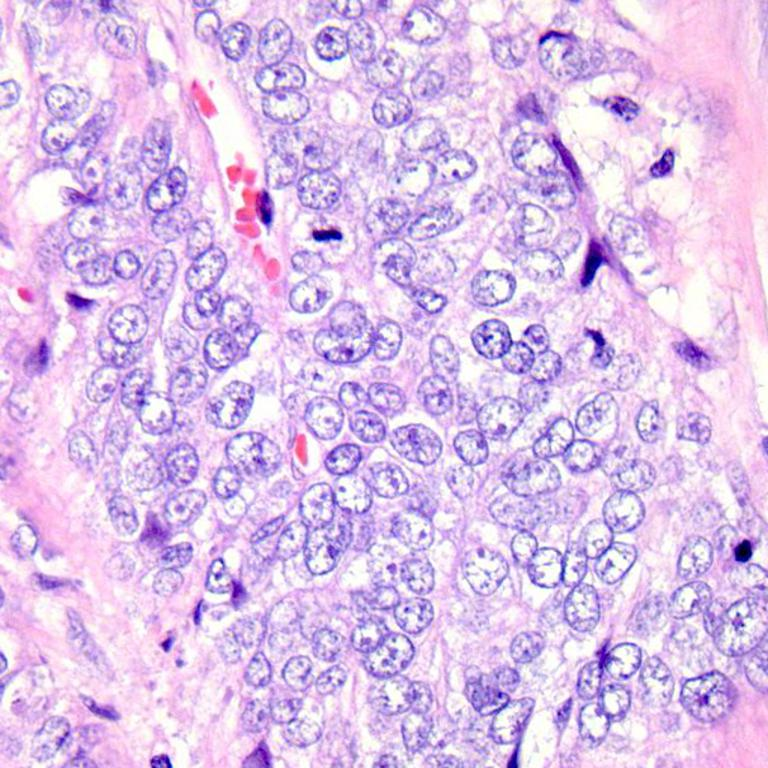

In [ ]:
import cv2
from google.colab.patches import cv2_imshow
import os # Import os module to check file existence

img = r"/content/lung_colon_image_set/colon_image_sets/colon_aca/colonca1.jpeg"

# Check if the file exists before reading
if os.path.exists(img):
    gp = cv2.imread(img)
    # Check if the image was successfully loaded
    if gp is not None:
        cv2_imshow(gp)
    else:
        print(f"Error: Could not read the image at {img}. The file might be corrupted.")
else:
    print(f"Error: Image file not found at {img}. Please check the path.")

In [ ]:


import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization

In [ ]:

dataset_dir = r"/content/lung_colon_image_set/colon_image_sets"

image_size = (224, 224)
batch_size = 32


In [ ]:
train_ds = image_dataset_from_directory(
    directory=dataset_dir,
    labels="inferred",
    label_mode="int",
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.3,
    subset="training",
    seed=42
)

# Apply data augmentation to training dataset
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1)
])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

validation_ds = image_dataset_from_directory(
    directory=dataset_dir,
    labels="inferred",
    label_mode="int",
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.3,
    subset="validation",
    seed=42
)

# Normalize images
def process(image, label):
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

Found 10000 files belonging to 2 classes.
Using 7000 files for training.
Found 10000 files belonging to 2 classes.
Using 3000 files for validation.


In [ ]:
train_ds = image_dataset_from_directory(
    directory=dataset_dir,
    labels="inferred",
    label_mode="int",
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.3,
    subset="training",
    seed=42
)

# Apply data augmentation to training dataset
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomTranslation(0.1, 0.1)
])
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))

validation_ds = image_dataset_from_directory(
    directory=dataset_dir,
    labels="inferred",
    label_mode="int",
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.3,
    subset="validation",
    seed=42
)

# Normalize images
def process(image, label):
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [ ]:

train_ds = image_dataset_from_directory(
    directory=dataset_dir,
    labels="inferred",
    label_mode="int",
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.3,
    subset="training",
    seed=42
)

validation_ds = image_dataset_from_directory(
    directory=dataset_dir,
    labels="inferred",
    label_mode="int",
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.3,
    subset="validation",
    seed=42
)

Found 10000 files belonging to 2 classes.
Using 7000 files for training.
Found 10000 files belonging to 2 classes.
Using 3000 files for validation.


In [ ]:

train_ds = image_dataset_from_directory(
    directory=dataset_dir,
    labels="inferred",
    label_mode="int",
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.3,
    subset="training",
    seed=42
)

validation_ds = image_dataset_from_directory(
    directory=dataset_dir,
    labels="inferred",
    label_mode="int",
    batch_size=batch_size,
    image_size=image_size,
    validation_split=0.3,
    subset="validation",
    seed=42
)

Found 10000 files belonging to 2 classes.
Using 7000 files for training.
Found 10000 files belonging to 2 classes.
Using 3000 files for validation.


In [ ]:
def process(image, label):
    image = tf.cast(image, tf.float32)
    image = (image - 127.5) / 127.5
    return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:

base_model.trainable = True


In [ ]:

# Build the model
model = Sequential([
    base_model,
    BatchNormalization(),
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.2),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(2, activation="softmax")
])



In [ ]:

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.SparseCategoricalAccuracy()]
)


In [ ]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True
)


In [ ]:

history = model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=50,
    callbacks=[early_stopping]
)


Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 176s 484ms/step - accuracy: 0.9489 - loss: 0.1441 - sparse_categorical_accuracy: 0.9489 - val_accuracy: 0.4820 - val_loss: 1.0724 - val_sparse_categorical_accuracy: 0.4820
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 77s 330ms/step - accuracy: 0.9884 - loss: 0.0408 - sparse_categorical_accuracy: 0.9884 - val_accuracy: 0.4820 - val_loss: 6.6509 - val_sparse_categorical_accuracy: 0.4820
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 73s 333ms/step - accuracy: 0.9910 - loss: 0.0340 - sparse_categorical_accuracy: 0.9910 - val_accuracy: 0.4820 - val_loss: 3.9420 - val_sparse_categorical_accuracy: 0.4820
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 74s 337ms/step - accuracy: 0.9938 - loss: 0.0202 - sparse_categorical_accuracy: 0.9938 - val_accuracy: 0.9610 - val_loss: 0.1525 - val_sparse_categorical_accuracy: 0.9610
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 82s 336ms/step - accuracy: 0.9952 - loss: 0.0183 - sparse_categorical_accuracy: 0.9952 - val_accuracy: 1.0000 - val

In [ ]:
model.save("colon.h5")

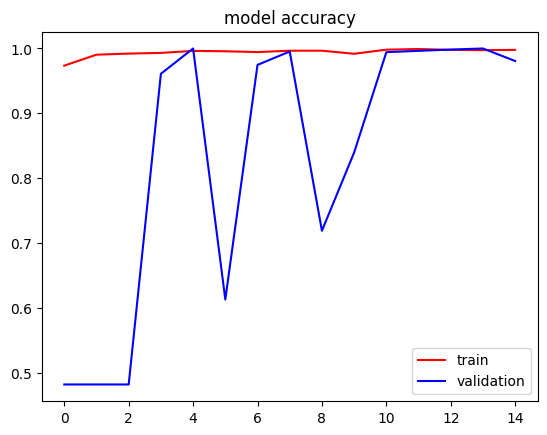

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color="red",label='train')
plt.plot(history.history['val_accuracy'],color="blue",label='validation')
plt.title("model accuracy")
plt.legend()
plt.show()


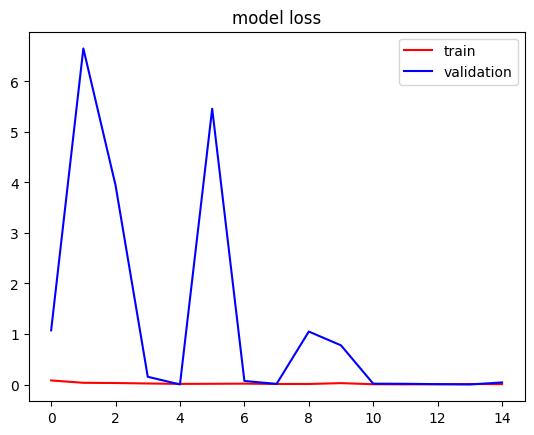

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['loss'],color="red",label='train')
plt.plot(history.history['val_loss'],color="blue",label='validation')
plt.title("model loss")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 140ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 148ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

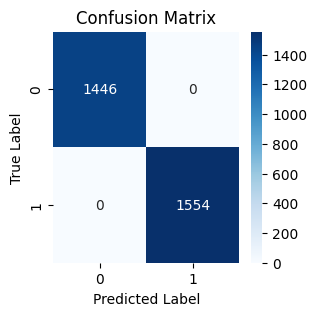

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1446
           1       1.00      1.00      1.00      1554

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in validation_ds:
    preds = model.predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(2), yticklabels=range(2))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred))


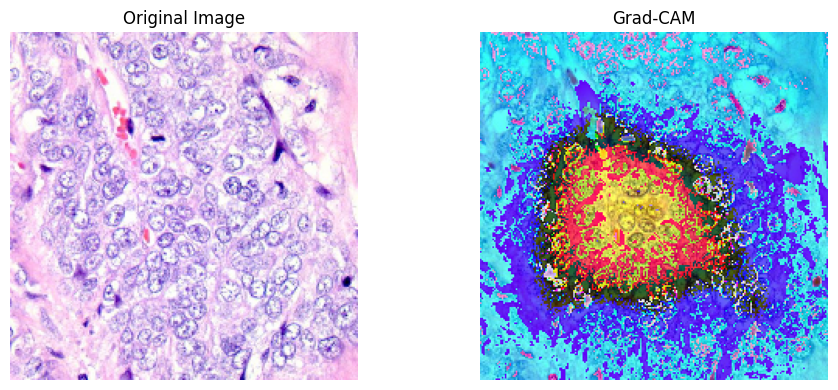

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image

# -----------------------------
# 1. Load or build your model
# -----------------------------
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
x = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)
preds = tf.keras.layers.Dense(1, activation='sigmoid')(x)  # For binary classification

model = Model(inputs=base_model.input, outputs=preds)

# -----------------------------
# 2. Grad-CAM Function
# -----------------------------
def get_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# -----------------------------
# 3. Overlay Heatmap
# -----------------------------
def superimpose_heatmap(heatmap, original_img, alpha=0.4):
    heatmap = cv2.resize(heatmap, (original_img.shape[1], original_img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap_color = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)
    superimposed_img = heatmap_color * alpha + original_img
    return superimposed_img.astype(np.uint8)

# -----------------------------
# 4. Load and preprocess image
# -----------------------------
def preprocess_input_custom(img_path):
    img = image.load_img(img_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    original_img = img_array.copy().astype(np.uint8)
    img_array = (img_array - 127.5) / 127.5
    img_array = np.expand_dims(img_array, axis=0)
    return img_array, original_img

# -----------------------------
# 5. Run Grad-CAM
# -----------------------------
img_path = "/content/lung_colon_image_set/colon_image_sets/colon_aca/colonca1.jpeg"  # Replace with your test image path
img_array, original_img = preprocess_input_custom(img_path)
heatmap = get_gradcam_heatmap(img_array, model, last_conv_layer_name="conv5_block3_out")  # Final conv layer of ResNet50
superimposed_img = superimpose_heatmap(heatmap, original_img)

# -----------------------------
# 6. Show Result
# -----------------------------
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(original_img.astype("uint8"))
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Grad-CAM")
plt.imshow(superimposed_img)

plt.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
from tensorflow.keras.applications import VGG16

# Load VGG16 base model
vgg_base = VGG16(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)
vgg_base.trainable = True  # Fine-tuning

# Build model
vgg_model = Sequential([
    vgg_base,
    BatchNormalization(),
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.2),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(2, activation="softmax")
])

vgg_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.SparseCategoricalAccuracy()]
)

vgg_history = vgg_model.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=50,
    callbacks=[early_stopping]
)

vgg_model.save("colon_vgg16.h5")


Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 181s 768ms/step - accuracy: 0.8307 - loss: 0.4089 - sparse_categorical_accuracy: 0.8307 - val_accuracy: 0.4820 - val_loss: 5.2143 - val_sparse_categorical_accuracy: 0.4820
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 114s 518ms/step - accuracy: 0.9569 - loss: 0.1184 - sparse_categorical_accuracy: 0.9569 - val_accuracy: 0.7593 - val_loss: 0.5199 - val_sparse_categorical_accuracy: 0.7593
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 147s 541ms/step - accuracy: 0.9753 - loss: 0.0689 - sparse_categorical_accuracy: 0.9753 - val_accuracy: 0.8220 - val_loss: 0.3860 - val_sparse_categorical_accuracy: 0.8220
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 115s 526ms/step - accuracy: 0.9818 - loss: 0.0505 - sparse_categorical_accuracy: 0.9818 - val_accuracy: 0.6410 - val_loss: 1.5966 - val_sparse_categorical_accuracy: 0.6410
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 146s 542ms/step - accuracy: 0.9897 - loss: 0.0350 - sparse_categorical_accuracy: 0.9897 - val_accuracy: 0.9877 -

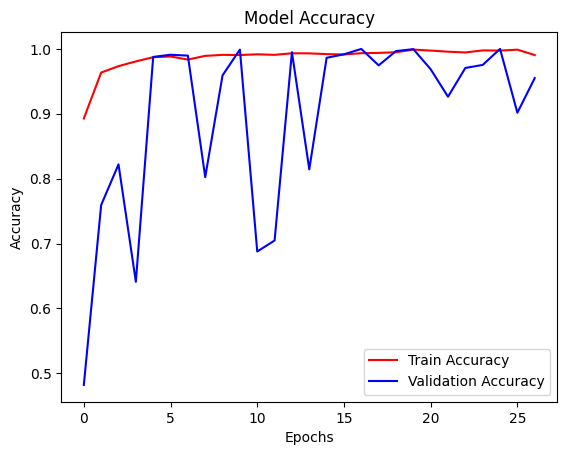

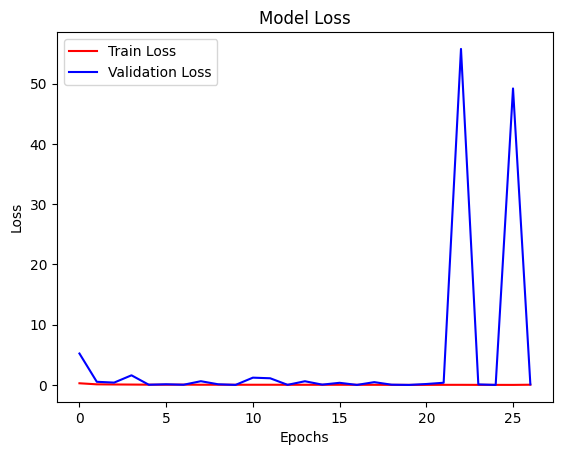

In [ ]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.plot(vgg_history.history['accuracy'], color="red", label='Train Accuracy')
plt.plot(vgg_history.history['val_accuracy'], color="blue", label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

# Plot Loss
plt.plot(vgg_history.history['loss'], color="red", label='Train Loss')
plt.plot(vgg_history.history['val_loss'], color="blue", label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 209ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 202ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 210ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 189ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 198ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

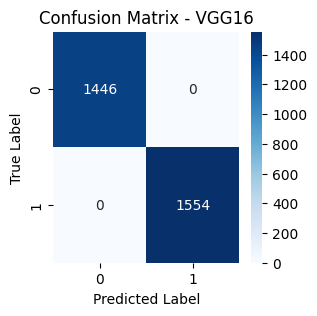

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1446
           1       1.00      1.00      1.00      1554

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

y_true = []
y_pred = []

# Loop through validation dataset
for images, labels in validation_ds:
    preds = vgg_model.predict(images)  # Use your VGG16 model here
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))  # Get predicted class index

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(2), yticklabels=range(2))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix - VGG16')
plt.show()

# Print classification report
print(classification_report(y_true, y_pred))


In [ ]:
from tensorflow.keras.applications import EfficientNetB0

base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = True

model_eff = Sequential([
    base_model,
    BatchNormalization(),
    GlobalAveragePooling2D(),
    BatchNormalization(),
    Dropout(0.2),
    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.2),
    Dense(2, activation="softmax")
])

model_eff.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy", tf.keras.metrics.SparseCategoricalAccuracy()]
)

history_eff = model_eff.fit(
    train_ds,
    validation_data=validation_ds,
    epochs=50,
    callbacks=[early_stopping]
)

model_eff.save("colon_efficientnet.h5")


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 217s 548ms/step - accuracy: 0.9519 - loss: 0.1200 - sparse_categorical_accuracy: 0.9519 - val_accuracy: 0.4820 - val_loss: 2.8489 - val_sparse_categorical_accuracy: 0.4820
Epoch 2/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 40s 181ms/step - accuracy: 0.9888 - loss: 0.0319 - sparse_categorical_accuracy: 0.9888 - val_accuracy: 0.4820 - val_loss: 4.9001 - val_sparse_categorical_accuracy: 0.4820
Epoch 3/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 39s 178ms/step - accuracy: 0.9972 - loss: 0.0095 - sparse_categorical_accuracy: 0.9972 - val_accuracy: 0.4820 - val_loss: 4.0540 - val_sparse_categorical_accuracy: 0.4820
Epoch 4/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 38s 172ms/step - accuracy: 0.9935 - loss: 0.0214 - sparse_categorical_accuracy: 0.9935 - val_accuracy: 0.4820 - val_loss: 3.7544 - val_sparse_categorical_accuracy: 0.4820
Epoch 5/50
219/219 ━━━━━━━━━━━━━━━━━━━━ 38s 173ms/step - accuracy: 0.9978 - loss: 0.0101 - sparse_catego

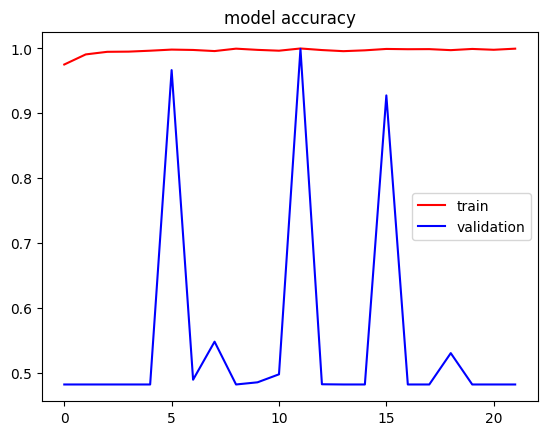

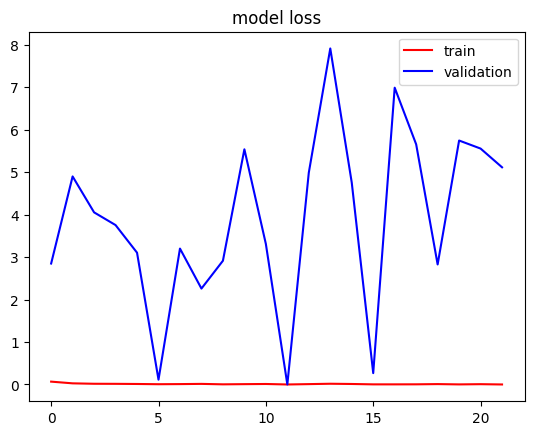

In [ ]:

import matplotlib.pyplot as plt
plt.plot(history_eff.history['accuracy'], color="red", label='train')
plt.plot(history_eff.history['val_accuracy'], color="blue", label='validation')
plt.title("model accuracy")
plt.legend()
plt.show()

plt.plot(history_eff.history['loss'], color="red", label='train')
plt.plot(history_eff.history['val_loss'], color="blue", label='validation')
plt.title("model loss")
plt.legend()
plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/ste

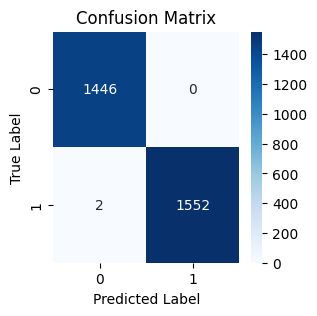

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1446
           1       1.00      1.00      1.00      1554

    accuracy                           1.00      3000
   macro avg       1.00      1.00      1.00      3000
weighted avg       1.00      1.00      1.00      3000



In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

y_true = []
y_pred = []

for images, labels in validation_ds:
    preds = model_eff .predict(images)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(3, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(2), yticklabels=range(2))
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

print(classification_report(y_true, y_pred))


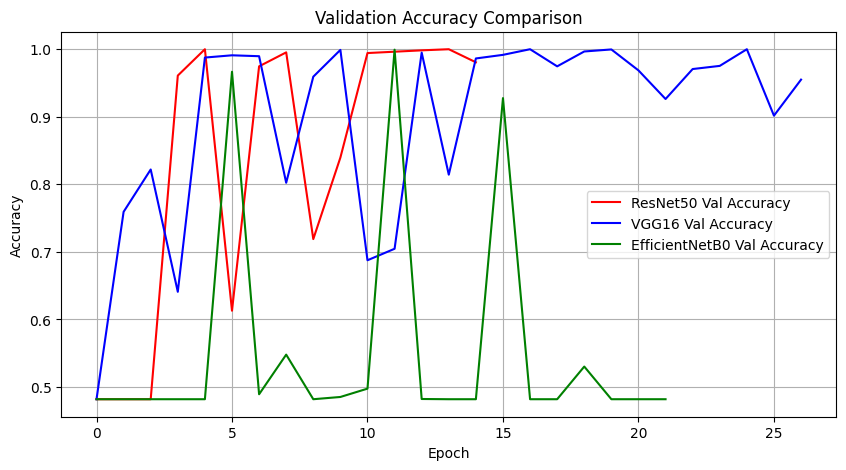

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(history.history['val_accuracy'], label='ResNet50 Val Accuracy', color='red')
plt.plot(vgg_history.history['val_accuracy'], label='VGG16 Val Accuracy', color='blue')
plt.plot(history_eff.history['val_accuracy'], label='EfficientNetB0 Val Accuracy', color='green')
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


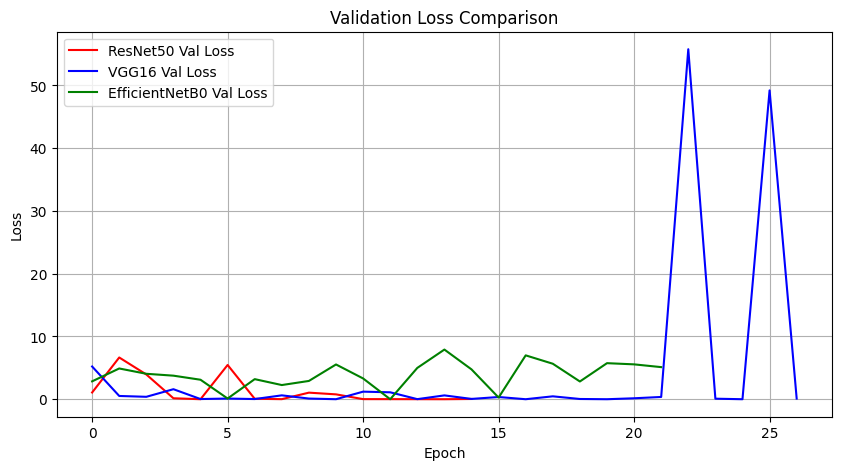

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['val_loss'], label='ResNet50 Val Loss', color='red')
plt.plot(vgg_history.history['val_loss'], label='VGG16 Val Loss', color='blue')
plt.plot(history_eff.history['val_loss'], label='EfficientNetB0 Val Loss', color='green')
plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()


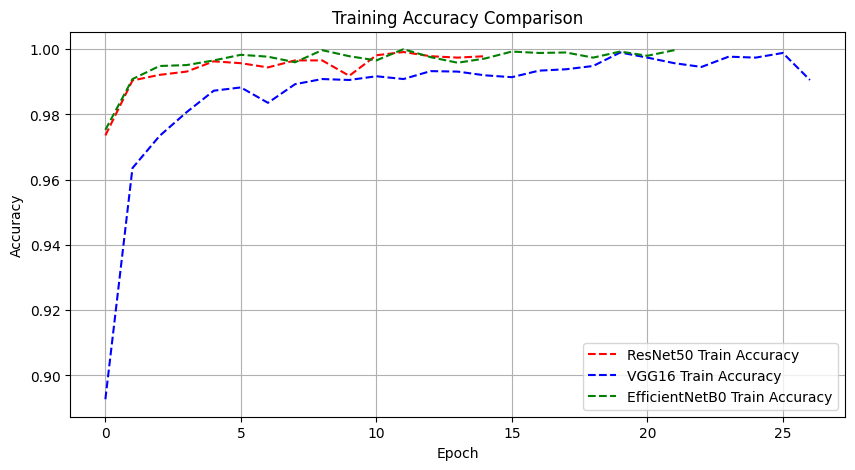

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(history.history['accuracy'], label='ResNet50 Train Accuracy', linestyle='--', color='red')
plt.plot(vgg_history.history['accuracy'], label='VGG16 Train Accuracy', linestyle='--', color='blue')
plt.plot(history_eff.history['accuracy'], label='EfficientNetB0 Train Accuracy', linestyle='--', color='green')
plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()



In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

def evaluate_model(model, validation_ds):
    y_true = []
    y_pred = []

    for images, labels in validation_ds:
        preds = model.predict(images)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))

    report = classification_report(y_true, y_pred, output_dict=True)
    cm = confusion_matrix(y_true, y_pred)

    return report, cm


In [ ]:
resnet_report, resnet_cm = evaluate_model(model, validation_ds)
vgg_report, vgg_cm = evaluate_model(vgg_model, validation_ds)
effnet_report, effnet_cm = evaluate_model(model_eff, validation_ds)


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 150ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 133ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 

/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 177ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 191ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 179ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 227ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 190ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
def extract_metrics(report_dict):
    return {
        'accuracy': report_dict['accuracy'],
        'precision': report_dict['weighted avg']['precision'],
        'recall': report_dict['weighted avg']['recall'],
        'f1-score': report_dict['weighted avg']['f1-score']
    }

summary = {
    'ResNet50': extract_metrics(resnet_report),
    'VGG16': extract_metrics(vgg_report),
    'EfficientNetB0': extract_metrics(effnet_report)
}


In [ ]:
import pandas as pd

df = pd.DataFrame(summary).T  # Transpose to make models as rows
df = df.round(4)  # Round to 4 decimal places
print(df)


                accuracy  precision  recall  f1-score
ResNet50          0.4820     0.2323  0.4820    0.3135
VGG16             1.0000     1.0000  1.0000    1.0000
EfficientNetB0    0.9993     0.9993  0.9993    0.9993


In [ ]:
pip install streamlit tensorflow pillow numpy


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 100.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 118.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 8.1 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
%cd /content/drive/MyDrive/


/content/drive/MyDrive


In [ ]:
!pip install streamlit
!npm install -g localtunnel


⠙⠹⠸⠼⠴⠦⠧⠇⠏⠋⠙⠹⠸⠼⠴⠦⠧
added 22 packages in 2s
⠧
⠧3 packages are looking for funding
⠧  run `npm fund` for details
⠧

In [ ]:
%%writefile launch.sh
#!/bin/bash
streamlit run app.py --server.port 8501 &
sleep 5
npx localtunnel --port 8501


Writing launch.sh


In [ ]:
!bash launch.sh





  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.87.48.48:8501

⠙⠹⠸⠼⠴⠦⠧⠇⠏your url is: https://afraid-phones-dress.loca.lt
